Number of schemes: 40
Number of return observations: 45960

Daily Return Summary:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


Missing daily returns: 0
Returns below -20%: 0
Returns above +20%: 0


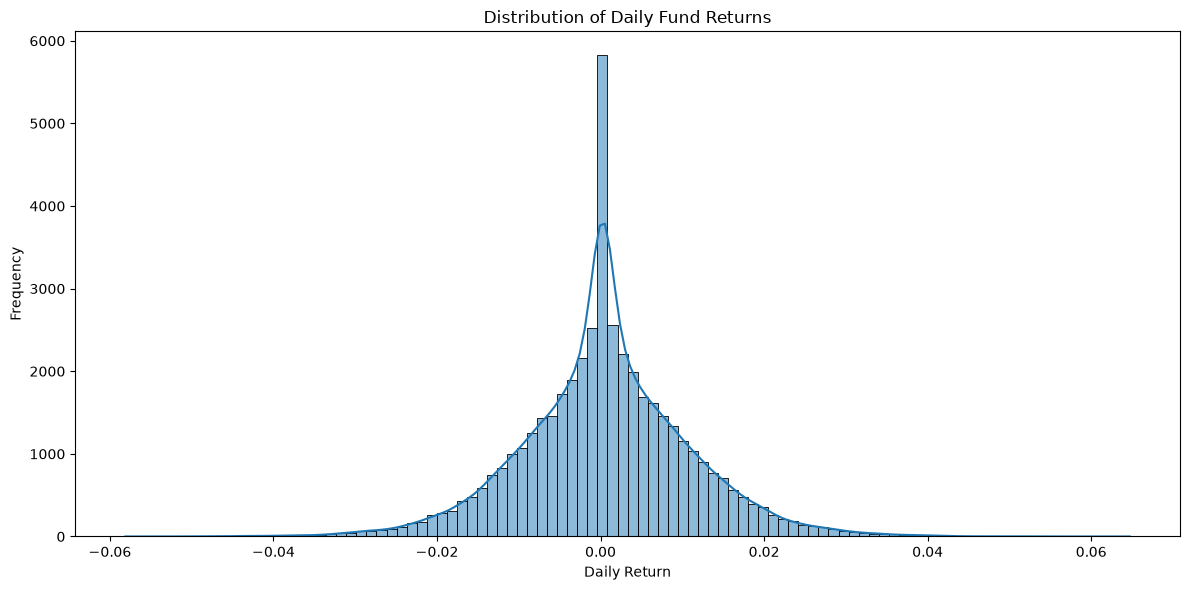


Daily returns calculated successfully.
Chart saved to Reports/Daily_Return_Distribution.png
Data saved to Data/Processed/daily_returns.csv


In [1]:

# DAY 4 - TASK 1: DAILY RETURNS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading NAV history:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

# Cleaning column names:
nav_df.columns = (
    nav_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Converting date and NAV:
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")
nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")

# Sorting correctly:
nav_df = nav_df.sort_values(["amfi_code", "date"]).copy()

# Calculate daily return for each scheme:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove rows where return cannot be calculated:
returns_df = nav_df.dropna(subset=["daily_return"]).copy()

# Basic validation:
print("Number of schemes:", returns_df["amfi_code"].nunique())
print("Number of return observations:", len(returns_df))

print("\nDaily Return Summary:")
display(returns_df["daily_return"].describe())

# Check for missing and extreme values:
print("\nMissing daily returns:", returns_df["daily_return"].isna().sum())
print(
    "Returns below -20%:",
    (returns_df["daily_return"] < -0.20).sum()
)
print(
    "Returns above +20%:",
    (returns_df["daily_return"] > 0.20).sum()
)

# Distribution of daily returns:
plt.figure(figsize=(12, 6))

sns.histplot(
    returns_df["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()

# Save chart:
plt.savefig(
    "../Reports/Daily_Return_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save calculated daily returns:
returns_df.to_csv(
    "../Data/Processed/daily_returns.csv",
    index=False
)

print("\nDaily returns calculated successfully.")
print("Chart saved to Reports/Daily_Return_Distribution.png")
print("Data saved to Data/Processed/daily_returns.csv")

In [3]:

# DAY 4 - TASK 2: CAGR ANALYSIS

import pandas as pd
import numpy as np

# Using the NAV data already loaded:
cagr_source = pd.read_csv("../Data/Raw/02_nav_history.csv")
cagr_source["date"] = pd.to_datetime(cagr_source["date"])

# Keeping required columns:
cagr_source = cagr_source[["amfi_code", "date", "nav"]].dropna()

# Making sure data is sorted:
cagr_source = cagr_source.sort_values(["amfi_code", "date"])

# Latest available date for each fund:
latest_dates = (
    cagr_source.groupby("amfi_code")["date"]
    .max()
    .reset_index()
)

results = []

# Calculating CAGR for each fund:
for _, row in latest_dates.iterrows():

    fund = row["amfi_code"]
    end_date = row["date"]

    fund_data = cagr_source[
        cagr_source["amfi_code"] == fund
    ].sort_values("date")

    end_nav = fund_data.loc[
        fund_data["date"] == end_date, "nav"
    ].iloc[0]

    fund_result = {
        "amfi_code": fund,
        "latest_date": end_date,
        "latest_nav": end_nav
    }

    for years in [1, 3, 5]:

        target_date = end_date - pd.DateOffset(years=years)

        # Finding the closest available date on or before target date:
        eligible = fund_data[
            fund_data["date"] <= target_date
        ]

        if len(eligible) == 0:
            fund_result[f"cagr_{years}yr"] = np.nan
        else:
            start_row = eligible.iloc[-1]
            start_nav = start_row["nav"]

            cagr = (
                (end_nav / start_nav) ** (1 / years)
            ) - 1

            fund_result[f"cagr_{years}yr"] = cagr

    results.append(fund_result)

# Creating comparison table:
cagr_df = pd.DataFrame(results)

# Convert CAGR to percentage:
for col in ["cagr_1yr", "cagr_3yr", "cagr_5yr"]:
    cagr_df[col] = cagr_df[col] * 100

# Display comparison table:
print("CAGR Comparison Across All Funds:")
display(cagr_df.head(40))

# Summary:
print("\nNumber of funds:", len(cagr_df))
print("1-Year CAGR available:", cagr_df["cagr_1yr"].notna().sum())
print("3-Year CAGR available:", cagr_df["cagr_3yr"].notna().sum())
print("5-Year CAGR available:", cagr_df["cagr_5yr"].notna().sum())

# Save CAGR comparison table:
cagr_df.to_csv(
    "../Data/Processed/CAGR_Comparison.csv",
    index=False
)

print("\nCAGR comparison saved to:")
print("../Reports/CAGR_Comparison.csv")

CAGR Comparison Across All Funds:


,amfi_code,latest_date,latest_nav,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,2026-05-29,583.6113,-2.224271,1.292649,NaN
1,100025,2026-05-29,31.8843,3.704969,3.916390,NaN
2,100033,2026-05-29,342.0072,53.232396,32.442459,NaN
3,101206,2026-05-29,773.2939,47.924120,28.967695,NaN
4,101207,2026-05-29,53.9836,-23.986032,-4.152381,NaN
5,101208,2026-05-29,410.1021,7.236645,6.315784,NaN
6,102885,2026-05-29,187.7797,20.207704,19.667262,NaN
7,102886,2026-05-29,125.5640,-16.797481,-0.767406,NaN
8,102887,2026-05-29,378.9657,13.583135,25.556188,NaN
9,118632,2026-05-29,110.5554,33.981048,22.652360,NaN



Number of funds: 40
1-Year CAGR available: 40
3-Year CAGR available: 40
5-Year CAGR available: 0

CAGR comparison saved to:
../Reports/CAGR_Comparison.csv


In [4]:

# DAY 4 - TASK 3: SHARPE RATIO

import pandas as pd
import numpy as np

# Loading daily returns:
returns_df = pd.read_csv("../Data/Processed/daily_returns.csv")
returns_df["date"] = pd.to_datetime(returns_df["date"])

# Annual risk-free rate:
rf_annual = 0.065

# Convert annual risk-free rate to daily rate:
rf_daily = (1 + rf_annual) ** (1 / 252) - 1

# Calculating Sharpe Ratio for every fund:
sharpe_results = []

for fund, data in returns_df.groupby("amfi_code"):

    daily_returns = data["daily_return"].dropna()

    if len(daily_returns) > 1:

        excess_return = daily_returns.mean() - rf_daily
        volatility = daily_returns.std()

        sharpe = (
            excess_return / volatility
        ) * np.sqrt(252)

    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": fund,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

# Rank funds:
sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

print("Sharpe Ratio Ranking:")
display(sharpe_df)

# Saving result:
sharpe_df.to_csv(
    "../Data/Processed/sharpe_ratio.csv",
    index=False
)

print("\nSharpe Ratio saved to:")
print("../Data/Processed/sharpe_ratio.csv")

Sharpe Ratio Ranking:


,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.462504,1.0
30,120843,1.319442,2.0
36,148569,1.246344,3.0
19,119551,1.222947,4.0
25,120505,1.190559,5.0
38,149323,1.143490,6.0
2,100033,1.104352,7.0
9,118632,1.095918,8.0
3,101206,1.041061,9.0
24,120504,1.040569,10.0



Sharpe Ratio saved to:
../Data/Processed/sharpe_ratio.csv


In [5]:

# DAY 4 - TASK 4: SORTINO RATIO

import pandas as pd
import numpy as np

# Loading daily returns:
returns_df = pd.read_csv("../Data/Processed/daily_returns.csv")

# Annual risk-free rate:
rf_annual = 0.065

# Converting to daily risk-free rate:
rf_daily = (1 + rf_annual) ** (1 / 252) - 1

sortino_results = []

for fund, data in returns_df.groupby("amfi_code"):

    daily_returns = data["daily_return"].dropna()

    if len(daily_returns) > 1:

        # Excess return:
        excess_return = daily_returns.mean() - rf_daily

        # Only negative returns are considered downside:
        downside_returns = daily_returns[
            daily_returns < 0
        ]

        if len(downside_returns) > 1:

            downside_deviation = downside_returns.std()

            sortino = (
                excess_return / downside_deviation
            ) * np.sqrt(252)

        else:
            sortino = np.nan

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

# Rank funds:
sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(ascending=False, method="min")
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

print("Sortino Ratio Ranking:")
display(sortino_df)

# Save result:
sortino_df.to_csv(
    "../Data/Processed/sortino_ratio.csv",
    index=False
)

print("\nSortino Ratio saved to:")
print("../Data/Processed/sortino_ratio.csv")

Sortino Ratio Ranking:


,amfi_code,sortino_ratio,sortino_rank
34,148567,2.409056,1.0
30,120843,2.387295,2.0
36,148569,2.166757,3.0
19,119551,2.166272,4.0
25,120505,2.047336,5.0
27,120507,1.918995,6.0
38,149323,1.893929,7.0
9,118632,1.874521,8.0
2,100033,1.846950,9.0
24,120504,1.829993,10.0



Sortino Ratio saved to:
../Data/Processed/sortino_ratio.csv


In [2]:
print(benchmark_df["index_name"].dropna().unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [ ]:

# DAY 4 - TASK 5: ALPHA & BETA

import pandas as pd
from scipy.stats import linregress

# Loading NAV data:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

# Loading benchmark data:
benchmark_df = pd.read_csv("../Data/Raw/10_benchmark_indices.csv")

# Converting dates:
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])


# NIFTY 100 benchmark:

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Calculating NIFTY 100 daily returns:
nifty100["nifty100_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100[
    ["date", "nifty100_return"]
].dropna()

print("NIFTY 100 return rows:", len(nifty100))


# Calculating fund returns:

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["fund_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

fund_returns = nav_df[
    ["amfi_code", "date", "fund_return"]
].dropna()


# Calculating Alpha and Beta:

results = []

for fund in fund_returns["amfi_code"].unique():

    fund_data = fund_returns[
        fund_returns["amfi_code"] == fund
    ]

    merged = fund_data.merge(
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["nifty100_return"],
        merged["fund_return"]
    )

    beta = regression.slope

    # Annualised Alpha:
    alpha = regression.intercept * 252

    results.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })


# Creating final table:

alpha_beta_df = pd.DataFrame(results)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)

print("\nAlpha & Beta results:")
display(alpha_beta_df.head(10))

print("\nNumber of funds analysed:", len(alpha_beta_df))


# Save result:

alpha_beta_df.to_csv(
    "../Data/Processed/alpha_beta.csv",
    index=False
)

print("\nSaved: Data/Processed/alpha_beta.csv")

NIFTY 100 return rows: 1149

Alpha & Beta results:


,amfi_code,alpha,beta
0,119598,0.303370,-0.023196
1,149324,0.300579,0.011455
2,120505,0.292636,0.000549
3,148569,0.282704,0.018134
4,120843,0.273305,-0.022830
5,100033,0.271954,0.005104
6,148567,0.269838,0.023684
7,149323,0.265986,-0.002523
8,119094,0.260767,-0.066265
9,119551,0.232010,-0.031751



Number of funds analysed: 40

Saved: Data/Processed/alpha_beta.csv


In [1]:

# DAY 4 - TASK 6: MAXIMUM DRAWDOWN

import pandas as pd
import numpy as np


# Loading NAV dataset:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

# Converting date:
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sorting data:
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)


# Calculating Maximum Drawdown:

results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    # Running maximum NAV:
    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    # Drawdown:
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"] - 1
    )

    # Worst drawdown:
    worst_index = fund_data["drawdown"].idxmin()

    worst_drawdown = fund_data.loc[
        worst_index, "drawdown"
    ]

    # Drawdown date:
    worst_date = fund_data.loc[
        worst_index, "date"
    ]

    results.append({
        "amfi_code": fund,
        "max_drawdown": worst_drawdown,
        "worst_drawdown_date": worst_date
    })


# Creating result table:

drawdown_df = pd.DataFrame(results)

drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
).reset_index(drop=True)

print("Maximum Drawdown Results:")
display(drawdown_df.head(10))


# Save processed data:

drawdown_df.to_csv(
    "../Data/Processed/max_drawdown.csv",
    index=False
)

print("\nSaved: Data/Processed/max_drawdown.csv")

Maximum Drawdown Results:


,amfi_code,max_drawdown,worst_drawdown_date
0,119599,-0.525742,2025-10-28
1,119095,-0.516778,2026-05-11
2,101207,-0.354469,2026-05-11
3,149324,-0.311719,2025-01-03
4,119598,-0.287060,2025-05-14
5,102886,-0.280011,2026-04-27
6,100016,-0.247344,2022-09-15
7,120842,-0.240035,2024-10-17
8,118634,-0.233449,2026-02-20
9,119093,-0.217514,2023-05-22



Saved: Data/Processed/max_drawdown.csv


In [2]:

# DAY 4 - TASK 7: FUND SCORECARD

import pandas as pd
import numpy as np


# Loading processed datasets:

cagr_df = pd.read_csv(
    "../Data/Processed/CAGR_Comparison.csv"
)

sharpe_df = pd.read_csv(
    "../Data/Processed/sharpe_ratio.csv"
)

alpha_beta_df = pd.read_csv(
    "../Data/Processed/alpha_beta.csv"
)

drawdown_df = pd.read_csv(
    "../Data/Processed/max_drawdown.csv"
)


# Loading fund master:

fund_master = pd.read_csv(
    "../Data/Raw/01_fund_master.csv"
)


# Finding required columns:

print("Fund Master columns:")
print(fund_master.columns.tolist())


# Preparing CAGR:

cagr_df = cagr_df[
    ["amfi_code", "cagr_3yr"]
].dropna()


# Preparing Sharpe Ratio:

sharpe_df = sharpe_df[
    ["amfi_code", "sharpe_ratio"]
].dropna()


# Preparing Alpha:

alpha_beta_df = alpha_beta_df[
    ["amfi_code", "alpha"]
].dropna()


# Preparing Maximum Drawdown:

drawdown_df = drawdown_df[
    ["amfi_code", "max_drawdown"]
].dropna()


# Combining all performance measures:

scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code", how="inner")
    .merge(alpha_beta_df, on="amfi_code", how="inner")
    .merge(drawdown_df, on="amfi_code", how="inner")
)


# Adding Expense Ratio:

expense_column = [
    col for col in fund_master.columns
    if "expense" in col.lower()
]

if len(expense_column) == 0:

    print(
        "\nExpense ratio column was not found."
    )

    print(
        "Fund Master columns:"
    )

    print(
        fund_master.columns.tolist()
    )

else:

    expense_column = expense_column[0]

    expense_df = fund_master[
        ["amfi_code", expense_column]
    ].copy()

    expense_df = expense_df.rename(
        columns={
            expense_column: "expense_ratio"
        }
    )

    scorecard = scorecard.merge(
        expense_df,
        on="amfi_code",
        how="left"
    )


# Calculating component ranks:

scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False, pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False, pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False, pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio"]
    .rank(ascending=True, pct=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, pct=True)
)


# Calculating final score:

scorecard["score"] = (
    30 * scorecard["return_rank"]
    + 25 * scorecard["sharpe_rank"]
    + 20 * scorecard["alpha_rank"]
    + 15 * scorecard["expense_rank"]
    + 10 * scorecard["drawdown_rank"]
)


# Ranking funds:

scorecard = scorecard.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

scorecard["rank"] = (
    scorecard.index + 1
)


# Displaying top funds:

print("Top Fund Scorecard:")
display(
    scorecard.head(10)
)


# Save scorecard:

scorecard.to_csv(
    "../Data/Processed/fund_scorecard.csv",
    index=False
)

print(
    "\nSaved: Data/Processed/fund_scorecard.csv"
)

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
Top Fund Scorecard:


,amfi_code,cagr_3yr,sharpe_ratio,alpha,max_drawdown,expense_ratio,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score,rank
0,102886,-0.767406,-0.194707,0.028969,-0.280011,1.51,0.925,0.925,1.000,0.6125,0.875,88.8125,1
1,100016,1.292649,-0.187650,0.037476,-0.247344,1.55,0.875,0.900,0.975,0.8000,0.850,88.7500,2
2,119095,-11.705807,-0.067926,0.048016,-0.516778,1.38,1.000,0.850,0.925,0.4250,0.975,85.8750,3
3,101207,-4.152381,0.170481,0.108971,-0.354469,1.53,0.975,0.725,0.675,0.7125,0.950,81.0625,4
4,119092,0.525887,0.045245,0.068995,-0.144016,1.64,0.900,0.800,0.750,0.9875,0.375,80.5625,5
5,119599,-1.337387,-0.049101,0.048824,-0.525742,0.72,0.950,0.825,0.900,0.1375,1.000,79.1875,6
6,120842,7.756004,0.087273,0.078044,-0.240035,1.56,0.700,0.775,0.725,0.8250,0.825,75.5000,7
7,100025,3.916390,-0.515438,0.042818,-0.043083,0.56,0.850,1.000,0.950,0.0500,0.100,71.2500,8
8,101208,6.315784,-0.417229,0.060861,-0.001622,0.79,0.775,0.975,0.825,0.2750,0.075,69.0000,9
9,118636,4.062205,-0.306013,0.050748,-0.083164,0.55,0.825,0.950,0.875,0.0250,0.150,67.8750,10



Saved: Data/Processed/fund_scorecard.csv


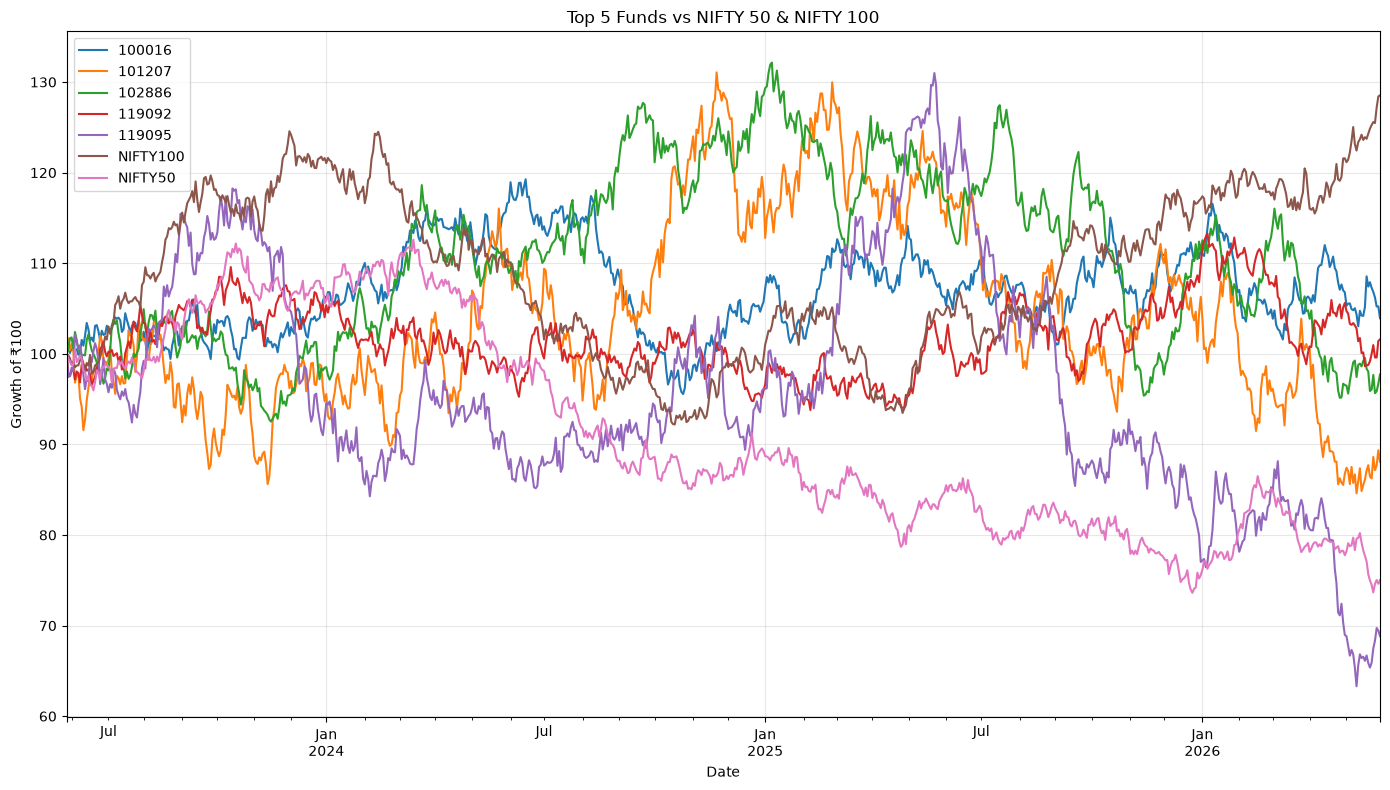

,amfi_code,benchmark,tracking_error
0,102886,NIFTY50,0.223602
1,102886,NIFTY100,0.223428
2,100016,NIFTY50,0.194617
3,100016,NIFTY100,0.195404
4,119095,NIFTY50,0.281588
5,119095,NIFTY100,0.283517
6,101207,NIFTY50,0.289987
7,101207,NIFTY100,0.293098
8,119092,NIFTY50,0.192282
9,119092,NIFTY100,0.185936



Saved:
Reports/Benchmark_Comparison.png
Data/Processed/tracking_error.csv


In [3]:

# DAY 4 - TASK 8: BENCHMARK COMPARISON

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Loading datasets:

scorecard = pd.read_csv(
    "../Data/Processed/fund_scorecard.csv"
)

nav = pd.read_csv(
    "../Data/Raw/02_nav_history.csv"
)

benchmark = pd.read_csv(
    "../Data/Raw/10_benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])


# Selecting top 5 funds and benchmarks:

top5 = scorecard.head(5)["amfi_code"].tolist()

benchmark = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]


# Preparing 3-year data:

end_date = benchmark["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nav = nav[
    (nav["date"] >= start_date) &
    (nav["date"] <= end_date) &
    (nav["amfi_code"].isin(top5))
]

benchmark = benchmark[
    (benchmark["date"] >= start_date) &
    (benchmark["date"] <= end_date)
]


# Creating price tables:

funds = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

indices = benchmark.pivot(
    index="date",
    columns="index_name",
    values="close_value"
)

prices = pd.concat(
    [funds, indices],
    axis=1
).ffill().dropna()


# Calculating growth from ₹100:

growth = prices / prices.iloc[0] * 100


# Plot benchmark comparison:

growth.plot(
    figsize=(14, 8),
    title="Top 5 Funds vs NIFTY 50 & NIFTY 100"
)

plt.ylabel("Growth of ₹100")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../Reports/Benchmark_Comparison.png",
    dpi=300
)

plt.show()


# Calculating tracking error:

returns = prices.pct_change().dropna()

tracking_error = []

for fund in top5:
    for index in ["NIFTY50", "NIFTY100"]:

        te = (
            returns[fund] - returns[index]
        ).std() * np.sqrt(252)

        tracking_error.append({
            "amfi_code": fund,
            "benchmark": index,
            "tracking_error": te
        })

tracking_error = pd.DataFrame(tracking_error)


# Displaying and saving results:

display(tracking_error)

tracking_error.to_csv(
    "../Data/Processed/tracking_error.csv",
    index=False
)

print("\nSaved:")
print("Reports/Benchmark_Comparison.png")
print("Data/Processed/tracking_error.csv")